# Statistical Testing — Neural Dynamics of Object Recognition Under Sensory Uncertainty

This notebook implements **group-level statistical tests** for the project hypotheses and reports
actual p-values. All tests are built on **statsmodels** (`statsmodels.api` / `statsmodels.formula.api`),
used in preference to scipy / sklearn.

The sliding-window SVM MVPA (`main.py`) produces, for every **subject x noise bin**, a decoding
accuracy curve. From those we derive two analysis tables:

- `df_subject` — one row per subject x noise bin (`peak_accuracy`, `peak_time`).
- `df_rep` — one row per subject x noise bin x MVPA repetition.

## Hypotheses and the statistical test used for each

| # | Hypothesis | Test (statsmodels) |
|---|------------|--------------------|
| H1 | Decoding accuracy is **above chance (0.5)** | One-sample t-test, implemented as an OLS intercept test (`sm.OLS`) |
| H2 | Accuracy **decreases** as sensory noise increases | Linear mixed-effects model, random intercepts per subject (`smf.mixedlm`) + cluster-robust OLS check |
| H3 | A **"breaking point"** (~40–50% noise) beyond which decoding returns to chance | Per-bin one-sample tests vs chance + multiple-comparison correction (`multipletests`), and segmented/piecewise regression breakpoint estimate (`smf.ols`) |
| H4 | Peak decoding **latency is delayed** as noise increases | Linear mixed-effects model of `peak_time` on noise (`smf.mixedlm`) |

The reusable functions live in `statistical_tests.py`.

In [12]:
# Setup and imports
import warnings
from importlib import reload

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ConvergenceWarning

import statistical_tests as st
reload(st)  # pick up edits to statistical_tests.py without restarting the kernel
from statistical_tests import CHANCE_LEVEL, DEFAULT_ALPHA

# The mixed models below are *expected* to warn: in H2 the between-subject
# variance is estimated at ~0 (the model collapses onto OLS) and the H4
# optimization hits the boundary. These warnings are analysed in the Notes
# section and do not invalidate the fixed-effect slopes, which are always
# cross-checked against cluster-robust OLS. Silence only this warning class so
# the output stays readable.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# --- Analysis configuration -------------------------------------------------
BASE_DIR = "."            # folder holding the 'mvpa_results - ...' output of main.py
CHANCE = CHANCE_LEVEL     # 0.5, chance decoding accuracy for 2 classes
ALPHA = DEFAULT_ALPHA     # significance level (0.05)
CORRECTION = "fdr_bh"     # multiple-comparison correction for H3 ('bonferroni' also allowed)

## 1. Load the group-level MVPA results

First we try to load the **real** results saved by `main.py`
(`subject_*_results.pkl` inside each `... noiseX.XXtoY.YY ...` folder).
If no results are present in this workspace, we fall back to a clearly-labelled
**simulated** dataset so the full statistical pipeline can be demonstrated.

In [11]:
# 1) Try to load real MVPA results produced by main.py
loaded = st.load_group_mvpa_results(BASE_DIR, source="all_channels")

if loaded is not None:
    df_subject, df_rep = loaded
    DATA_SOURCE = "Real MVPA results (main.py output)"
else:
    print("=" * 70)
    print("WARNING: No saved MVPA results found under:", BASE_DIR)
    print("Falling back to a SIMULATED demo dataset so the statistics can")
    print("be demonstrated. Re-run main.py and point BASE_DIR at its output")
    print("folders to analyze the real data.")
    print("=" * 70)
    df_subject, df_rep = st.simulate_group_dataset(
        n_subjects=7, n_repetitions=10, seed=42)
    DATA_SOURCE = "SIMULATED demo data (replace with real results!)"

print("\nData source:", DATA_SOURCE)
print(f"df_subject: {len(df_subject)} rows | df_rep: {len(df_rep)} rows")
df_subject.sort_values(["subject", "noise_center"]).head(10)

Loaded 35 subject-level and 350 repetition-level observations from 5 noise bins.

Data source: Real MVPA results (main.py output)
df_subject: 35 rows | df_rep: 350 rows


,subject,channel,noise_bin,noise_min,noise_max,noise_center,peak_accuracy,peak_time
0,0,ALL_CHANNELS,0.0-0.2,0.0,0.2,0.1,0.734783,405.0
7,0,ALL_CHANNELS,0.2-0.4,0.2,0.4,0.3,0.657778,365.0
14,0,ALL_CHANNELS,0.4-0.6,0.4,0.6,0.5,0.622222,195.0
21,0,ALL_CHANNELS,0.6-0.8,0.6,0.8,0.7,0.586667,455.0
28,0,ALL_CHANNELS,0.8-1.0,0.8,1.0,0.9,0.573333,225.0
1,1,ALL_CHANNELS,0.0-0.2,0.0,0.2,0.1,0.745652,325.0
8,1,ALL_CHANNELS,0.2-0.4,0.2,0.4,0.3,0.704444,445.0
15,1,ALL_CHANNELS,0.4-0.6,0.4,0.6,0.5,0.584444,-165.0
22,1,ALL_CHANNELS,0.6-0.8,0.6,0.8,0.7,0.573333,5.0
29,1,ALL_CHANNELS,0.8-1.0,0.8,1.0,0.9,0.580000,405.0


## 2. H1 — Is decoding accuracy above chance (0.5)?

For each noise bin (and pooled across all bins) we test, across subjects,
whether peak decoding accuracy exceeds the 0.5 chance level.

The one-sample t-test is implemented with statsmodels by regressing
`(accuracy - 0.5)` on a constant: the intercept t-test **is** the one-sample
t-test. `p_greater` is the one-sided p-value for accuracy > chance.

In [3]:
h1 = st.h1_above_chance(df_subject, chance=CHANCE)

print("H1: one-sample tests of decoding accuracy vs chance (0.5)\n")
print(h1.to_string(index=False, float_format=lambda x: f"{x:0.4g}"))

lowest = h1.iloc[0]
print(f"\n=> Lowest-noise bin ({lowest['noise_bin']}): "
      f"mean={lowest['mean']:.3f}, t({int(lowest['df'])})={lowest['t']:.2f}, "
      f"one-sided p={lowest['p_greater']:.3e}")

H1: one-sample tests of decoding accuracy vs chance (0.5)

noise_bin  noise_center  n   mean      sd     t  df  p_greater  p_two_sided  ci_low  ci_high
  0.0-0.2           0.1  7 0.7398 0.07377 8.599   6  6.803e-05    0.0001361  0.6715    0.808
  0.2-0.4           0.3  7 0.6873 0.04177 11.87   6  1.084e-05    2.168e-05  0.6487   0.7259
  0.4-0.6           0.5  7 0.5924 0.02262  10.8   6  1.859e-05    3.719e-05  0.5715   0.6133
  0.6-0.8           0.7  7 0.5857 0.02123 10.68   6  1.987e-05    3.973e-05  0.5661   0.6054
  0.8-1.0           0.9  7 0.5756 0.01846 10.83   6  1.835e-05    3.671e-05  0.5585   0.5926
      ALL           NaN  7 0.6361 0.01938 18.58   6  7.832e-07    1.566e-06  0.6182   0.6541

=> Lowest-noise bin (0.0-0.2): mean=0.740, t(6)=8.60, one-sided p=6.803e-05


## 3. H2 — Does decoding accuracy decrease with sensory noise?

Because every subject contributes repeated measurements (5 noise bins x 10
repetitions), the correct model accounts for within-subject dependence. We fit a
**linear mixed-effects model** with a random intercept per subject:

`(peak_accuracy - 0.5) ~ noise_center + (1 | subject)`

A cluster-robust (subject-level) OLS is reported as a sensitivity check.

In [4]:
h2 = st.h2_accuracy_trend(df_rep, chance=CHANCE)

print(h2["mixed"].summary())

print("=" * 70)
print(f"Mixed-model slope = {h2['slope_mixed']:.3f} accuracy units per unit noise")
print(f"One-sided p (accuracy DECREASES with noise) = {h2['p_mixed_decrease']:.3e}")
print(f"Cluster-robust OLS check: slope = {h2['slope_ols']:.3f}, "
      f"one-sided p = {h2['p_ols_decrease']:.3e}")

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: acc_vs_chance
No. Observations: 350     Method:             ML           
No. Groups:       7       Scale:              0.0032       
Min. group size:  50      Log-Likelihood:     504.6283     
Max. group size:  50      Converged:          Yes          
Mean group size:  50.0                                     
-----------------------------------------------------------
                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept        0.287    0.008  34.926 0.000  0.270  0.303
noise_center    -0.184    0.011 -17.292 0.000 -0.205 -0.163
Group Var        0.000    0.003                            

Mixed-model slope = -0.184 accuracy units per unit noise
One-sided p (accuracy DECREASES with noise) = 2.686e-67
Cluster-robust OLS check: slope = -0.184, one-sided p = 1.123e-05


c:\Users\Administrator\Desktop\compneuro\neuromatch 2025\NMA Final Project\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## 4. H3 — Is there a "breaking point"?

Two complementary approaches:

1. **Per-bin chance tests + correction.** For each noise bin we test accuracy vs
   chance across subjects, then correct the 5 bin-wise p-values for multiple
   comparisons (Benjamini–Hochberg FDR by default). The breaking point is the
   transition between the last significant and the first non-significant bin.
2. **Segmented (piecewise) regression.** We fit
   `accuracy ~ noise_center + max(noise_center - bp, 0)` over a grid of candidate
   breakpoints, select the breakpoint with the lowest AIC, and test whether the
   post-break slope change (the "hinge" term) is significant.

In [5]:
h3 = st.h3_breaking_point(df_subject, alpha=ALPHA, chance=CHANCE,
                          correction=CORRECTION)

print("H3: per-bin tests vs chance with", h3["correction"], "correction\n")
tab = h3["table"][["noise_bin", "noise_center", "mean", "p_greater",
                   "p_corrected", "significant"]]
print(tab.to_string(index=False, float_format=lambda x: f"{x:0.4g}"))

if h3["breaking_point"] is not None:
    print(f"\n=> Breaking point (significant -> non-significant) ~= "
          f"{h3['breaking_point']:.2f} noise")
else:
    print("\n=> No significant->non-significant transition detected.")

bp_fit = st.estimate_breakpoint(df_rep)
print("\nSegmented regression:")
print(f"  estimated breakpoint (min AIC) = {bp_fit.get('breakpoint'):.2f} noise")
print(f"  hinge (slope-change) p-value   = {bp_fit.get('hinge_p'):.3e}")
print(f"  AIC piecewise = {bp_fit.get('aic'):.1f} vs AIC linear = "
      f"{bp_fit.get('aic_linear_model'):.1f}")

H3: per-bin tests vs chance with fdr_bh correction

noise_bin  noise_center   mean  p_greater  p_corrected  significant
  0.0-0.2           0.1 0.7398  6.803e-05    6.803e-05         True
  0.2-0.4           0.3 0.6873  1.084e-05    2.483e-05         True
  0.4-0.6           0.5 0.5924  1.859e-05    2.483e-05         True
  0.6-0.8           0.7 0.5857  1.987e-05    2.483e-05         True
  0.8-1.0           0.9 0.5756  1.835e-05    2.483e-05         True

=> No significant->non-significant transition detected.

Segmented regression:
  estimated breakpoint (min AIC) = 0.53 noise
  hinge (slope-change) p-value   = 2.638e-04
  AIC piecewise = -1034.6 vs AIC linear = -993.2


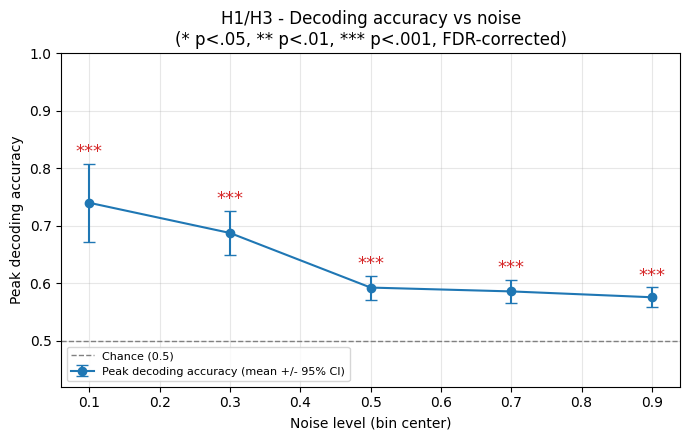

In [6]:
# Plot: group accuracy vs noise with significance stars and breaking point
fig, ax = plt.subplots(figsize=(7, 4.5))
tab = h3["table"]

yerr_low = tab["mean"] - tab["ci_low"]
yerr_high = tab["ci_high"] - tab["mean"]
ax.errorbar(tab["noise_center"], tab["mean"],
            yerr=[yerr_low, yerr_high],
            fmt="o-", capsize=4, color="tab:blue",
            label="Peak decoding accuracy (mean +/- 95% CI)")

ax.axhline(CHANCE, color="gray", ls="--", lw=1, label="Chance (0.5)")

# significance stars (corrected p-values)
for _, row in tab.iterrows():
    if row["significant"]:
        p = row["p_corrected"]
        star = "***" if p < 0.001 else ("**" if p < 0.01 else "*")
        ax.text(row["noise_center"], row["ci_high"] + 0.012, star,
                ha="center", fontsize=13, color="tab:red")

if h3["breaking_point"] is not None:
    ax.axvline(h3["breaking_point"], color="tab:red", ls=":",
               label=f"Breaking point = {h3['breaking_point']:.2f}")

ax.set_xlabel("Noise level (bin center)")
ax.set_ylabel("Peak decoding accuracy")
ax.set_title("H1/H3 - Decoding accuracy vs noise\n(* p<.05, ** p<.01, *** p<.001, FDR-corrected)")
ax.set_ylim(CHANCE - 0.08, 1.0)
ax.legend(loc="lower left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. H4 — Is peak decoding latency delayed by noise?

We test whether the time of peak decoding (`peak_time`, ms) increases with noise
using a mixed-effects model with a random intercept per subject:

`peak_time ~ noise_center + (1 | subject)`

In [7]:
h4 = st.h4_latency_trend(df_rep)

print(h4["mixed"].summary())

print("=" * 70)
print(f"Mixed-model slope = {h4['slope_mixed']:.1f} ms per unit noise (0->1)")
print(f"One-sided p (latency INCREASES with noise) = {h4['p_mixed_increase']:.3e}")
print(f"Cluster-robust OLS check: slope = {h4['slope_ols']:.1f} ms, "
      f"one-sided p = {h4['p_ols_increase']:.3e}")

            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  peak_time 
No. Observations:    350      Method:              ML        
No. Groups:          7        Scale:               31188.3648
Min. group size:     50       Log-Likelihood:      -2307.5661
Max. group size:     50       Converged:           No        
Mean group size:     50.0                                    
-------------------------------------------------------------
              Coef.   Std.Err.   z    P>|z|  [0.025   0.975] 
-------------------------------------------------------------
Intercept     373.421   19.221 19.428 0.000  335.749  411.094
noise_center -330.786   33.375 -9.911 0.000 -396.199 -265.373
Group Var      13.070    1.969                               

Mixed-model slope = -330.8 ms per unit noise (0->1)
One-sided p (latency INCREASES with noise) = 1.000e+00
Cluster-robust OLS check: slope = -330.8 ms, one-sided p = 1.000e+00


c:\Users\Administrator\Desktop\compneuro\neuromatch 2025\NMA Final Project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Administrator\Desktop\compneuro\neuromatch 2025\NMA Final Project\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\Administrator\Desktop\compneuro\neuromatch 2025\NMA Final Project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Administrator\Desktop\compneuro\neuromatch 2025\NMA Final Project\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  

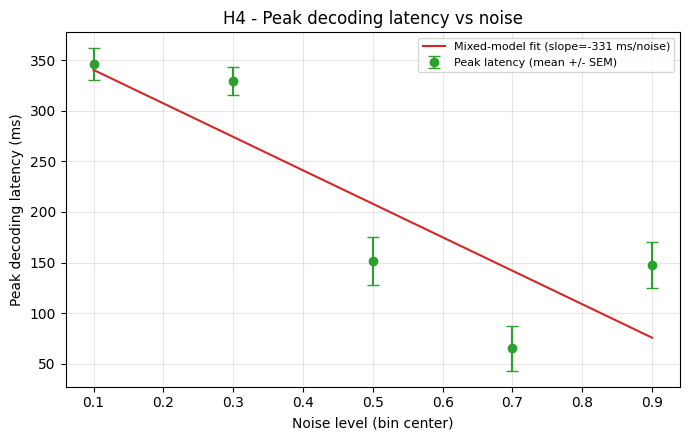

In [8]:
# Plot: peak latency vs noise with the mixed-model fixed-effect fit
grp = df_rep.groupby("noise_center")["peak_time"].agg(["mean", "sem"]).reset_index()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(grp["noise_center"], grp["mean"], yerr=grp["sem"],
            fmt="o", capsize=4, color="tab:green",
            label="Peak latency (mean +/- SEM)")

params = h4["mixed"].params
xs = np.linspace(df_rep["noise_center"].min(), df_rep["noise_center"].max(), 50)
ax.plot(xs, params["Intercept"] + params["noise_center"] * xs,
        "-", color="tab:red",
        label=f"Mixed-model fit (slope={h4['slope_mixed']:.0f} ms/noise)")

ax.set_xlabel("Noise level (bin center)")
ax.set_ylabel("Peak decoding latency (ms)")
ax.set_title("H4 - Peak decoding latency vs noise")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary of all hypothesis tests

A single table of every test, its statistic and p-value. Results are also saved
to `statistics_summary.csv`.

In [9]:
results, summary = st.run_all_tests(df_subject, df_rep,
                                    alpha=ALPHA, chance=CHANCE,
                                    correction=CORRECTION)

print("Data source:", DATA_SOURCE, "\n")
print(summary.to_string(index=False, float_format=lambda x: f"{x:0.4g}"))

summary.to_csv("statistics_summary.csv", index=False)
print("\nSaved summary -> statistics_summary.csv")

c:\Users\Administrator\Desktop\compneuro\neuromatch 2025\NMA Final Project\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\Administrator\Desktop\compneuro\neuromatch 2025\NMA Final Project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Administrator\Desktop\compneuro\neuromatch 2025\NMA Final Project\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\Administrator\Desktop\compneuro\neuromatch 2025\NMA Final Project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  war

Data source: Real MVPA results (main.py output) 

                                hypothesis                               test  statistic   p_value  significant
  H1: accuracy > chance (lowest noise bin)       one-sample t (OLS intercept)      8.599 6.803e-05         True
         H2: accuracy decreases with noise        mixed-effects model (slope)    -0.1843 2.686e-67         True
               H3: breaking point (fdr_bh) per-bin tests + corrected p-values        NaN       NaN        False
H3: accuracy drop at cliff (adjacent bins)       paired t-test, FDR-corrected      4.756   0.01255         True
            H3: slope change at breakpoint  segmented regression (hinge term)     0.2851 0.0002638         True
     H4: peak latency increases with noise        mixed-effects model (slope)     -330.8         1        False

Saved summary -> statistics_summary.csv


c:\Users\Administrator\Desktop\compneuro\neuromatch 2025\NMA Final Project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Administrator\Desktop\compneuro\neuromatch 2025\NMA Final Project\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\Administrator\Desktop\compneuro\neuromatch 2025\NMA Final Project\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.076557
  warnings.warn(msg, ConvergenceWarning)


## Notes

- **Interpretation of one-sided p-values.** H2 and H4 are directional
  hypotheses (accuracy *decreases*, latency *increases*), so we report one-sided
  p-values derived from the two-sided statsmodels output. If you prefer
  two-sided values, use the `*_two_sided` fields returned by each function.
- **Independence of observations.** The 10 MVPA repetitions per condition are
  random train/test splits of the *same* trials, so repetition-level rows are
  not fully independent. The mixed-model p-values in H2/H4 (n = 350 rows) are
  therefore the optimistic view; the subject-level cluster-robust OLS reported
  alongside them is the conservative check. The tests that decide H1 and H3 run
  on one observation per subject per bin (n = 7), and the pooled H1 `ALL` row
  averages each subject over bins so that every subject contributes exactly one
  independent observation (no pseudo-replication).
- **Peak-search window.** The decoder runs over the whole `-200..500 ms` window
  and `peak_accuracy` / `peak_time` are the argmax of that curve, so in
  high-noise bins a noisy *pre-stimulus* window can be selected as the "peak"
  (in the current data 4/35 subject-level and 79/350 repetition-level peaks fall
  at or before 0 ms, nearly all in the 0.4–0.8 noise bins). Pass
  `min_peak_time=0.0` to `load_group_mvpa_results` to restrict the peak search
  to post-stimulus windows — a useful sensitivity check for H4 and for the
  interpretation of peak accuracy.
- **Multiple comparisons.** H3 tests 5 noise bins, so the bin-wise p-values are
  corrected (Benjamini-Hochberg FDR by default). Set `CORRECTION = "bonferroni"`
  for a more conservative test.
- **Segmented-regression breakpoint.** The breakpoint is chosen by AIC over a
  grid of candidates, so the hinge p-value at the selected breakpoint is
  descriptive (it is not corrected for the search over candidates) — treat it as
  supporting evidence for the adjacent-bin paired t-test, not as a stand-alone
  confirmatory test.
- **Mixed-model convergence warnings.** statsmodels may warn that the MLE is on
  the boundary of the parameter space (H2: between-subject variance estimated at
  ~0, so the mixed model collapses onto OLS) or that optimization failed to
  converge (H4). In both cases the fixed-effect slope is still estimated, but
  the cluster-robust OLS check is the result to trust; the H2/H4 conclusions are
  identical under it.
- **Using the real data.** Once the MVPA pipeline (`main.py`) has been run and
  the `... noiseX.XXtoY.YY ...` result folders exist in this directory, the first
  code cell will load them automatically and all tests will run on the real
  results instead of the simulated demo data. To test single-channel decoding
  instead of the all-channel decoder, call
  `st.load_group_mvpa_results(BASE_DIR, source="single_channels")`.